# Background

```mermaid
flowchart LR

A[Data] --> B[Numeric]
A --> C[Categorical]

```

### Exploratory Data Analysis

AKA Descriptive data analysis

```mermaid
flowchart TB

A[Exploratory Data Analysis] --> B1[Summaries]
A --> C[Visualization]
A --> D[Hypothesis Testing]


```

### Hypothesis Testing 

$$\alpha = 0.05$$

```mermaid
flowchart LR 

A[Hypothesis tests] -->B[Numeric vs Numeric] --> B2["Pearson's Correlations test"]
A --> C[Numeric vs Binary] --> Cb[Ttest]
A --> C2[Numeric vs Categorical] --> C2b["Analysis of variance AKA ANOVA"]
A --> D[Categorical vs Categorical] --> Db[Chisquared test]

B --> B3["Spearman Correlation test"]
C --> Cc[Wilcoxon test]
C2 --> C2c[Kruskal Wallis test]
D --> Dc[Fishers Exact test]

```

In [3]:
library(tidyverse)
library(gtsummary)

In [2]:
nhanes <- read_csv("data/nhanes.csv")

Rows: 20293 Columns: 78
── Column specification ─────────────────────────────────────────────────────────────────
Delimiter: ","
chr (29): SurveyYr, Gender, Race1, Race3, Education, MaritalStatus, HHIncome, HomeOwn...
dbl (49): ID, Age, AgeMonths, HHIncomeMid, Poverty, HomeRooms, Weight, Length, HeadCi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
nhanes |> 
  filter(Age < 18) -> children

In [5]:
nhanes |> 
  filter(Age >= 18) -> adults

In [ ]:
#Correlation
children |> select(Age, Height) |> cor(use = 'complete.obs')

             Age    Height
Age    1.0000000 0.9526951
Height 0.9526951 1.0000000

In [ ]:
#correlation test
children |> with(cor.test(Age, Height))


	Pearson's product-moment correlation

data:  Age and Height
t = 246.88, df = 6203, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.9503409 0.9549404
sample estimates:
      cor 
0.9526951 


In [11]:
adults |> select(Age, Height) |> cor(use='complete.obs')

              Age     Height
Age     1.0000000 -0.1648494
Height -0.1648494  1.0000000

In [17]:
adults |> with(cor.test(Age, Height)) 


	Pearson's product-moment correlation

data:  Age and Height
t = -18.177, df = 11828, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.1823282 -0.1472665
sample estimates:
       cor 
-0.1648494 


In [21]:
#Num vs Binary

adults |> group_by(Gender) |> summarise(
  Mean=mean(Height, na.rm=T), 
  SD=sd(Height, na.rm=T)
)

# A tibble: 2 × 3
  Gender  Mean    SD
  <chr>  <dbl> <dbl>
1 female  161.  7.32
2 male    174.  7.81

In [25]:
adults  |> with(t.test(Height ~ Gender))


	Welch Two Sample t-test

data:  Height by Gender
t = -98.113, df = 11704, p-value < 2.2e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -13.93766 -13.39165
sample estimates:
mean in group female   mean in group male 
            160.6204             174.2850 


In [27]:
adults |> 
  group_by(Race1) |> 
  summarise(
    Mean=mean(Height, na.rm=T), 
    SD=sd(Height, na.rm=T)
  )

# A tibble: 5 × 3
  Race1     Mean    SD
  <chr>    <dbl> <dbl>
1 Black     169.  9.71
2 Hispanic  163.  9.81
3 Mexican   163.  9.66
4 Other     165.  9.57
5 White     169. 10.0 

In [29]:
adults |> 
  with(aov(Height ~ Race1)) |> 
  summary()

               Df  Sum Sq Mean Sq F value Pr(>F)    
Race1           4   87344   21836   226.3 <2e-16 ***
Residuals   11825 1141263      97                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
561 observations deleted due to missingness

In [31]:
adults |> 
  with(aov(Height ~ Gender)) |> 
  summary()

               Df Sum Sq Mean Sq F value Pr(>F)    
Gender          1 552020  552020    9650 <2e-16 ***
Residuals   11828 676587      57                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
561 observations deleted due to missingness

In [34]:
adults |> 
  select(Race1, Education) |> 
  table() |> 
  chisq.test()


	Pearson's Chi-squared test

data:  table(select(adults, Race1, Education))
X-squared = 2227.4, df = 16, p-value < 2.2e-16


In [37]:
#

In [ ]:
#Non normal numeric variables
#numeric vs numeric - spearman

children |> with(cor.test(Age, Height, method='spearman'))

Warning message:
In cor.test.default(Age, Height, method = "spearman") :
  Cannot compute exact p-value with ties



	Spearman's rank correlation rho

data:  Age and Height
S = 1571287669, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.9605378 


In [ ]:
#numeric vs binary
#Wilcox Rank Sum Test (Wilcox or Wilcoxon)
adults |> with(wilcox.test(Height ~ Gender))


	Wilcoxon rank sum test with continuity correction

data:  Height by Gender
W = 3502661, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


In [47]:
#numeric vs categorical
#Kruskal Wallis Test
adults |> with(kruskal.test(Height ~ Race1))


	Kruskal-Wallis rank sum test

data:  Height by Race1
Kruskal-Wallis chi-squared = 805.29, df = 4, p-value < 2.2e-16


In [ ]:
#fisher.test

In [72]:
#Gtsummary

adults |> 
  filter(!is.na(Diabetes)) |> 
  tbl_summary(
    include = c(Age, Gender, Race1, BMI), 
    label = list(Gender ~ 'Sex', Race1 ~ 'Race', BMI ~ 'Body Mass Index'), 
    statistic = list(Age ~ '{mean} (±{sd})'),
    by = Diabetes, 
    missing = 'no'
  ) |> 
  add_overall() |> 
  add_p(test=list(Age ~ 't.test')) |> 
  bold_labels() |> # Make variable labels bold
  modify_caption("**Table 1. Baseline Characteristics by Treatment Group**") # Add a title

# --- 3. Print the Table ---

<R HTML widget HTML Widget>

In [60]:
#Tidyverse
#Dplyr selcet, filter, arrange, group_by, summarize, mutate
#GGplot2
#Lubridate
#Forcats
#Purrr

In [66]:
adults |> 
  mutate(Gender = fct_rev(Gender)) |> 
  mutate(Education = fct_relevel(Education, '8th Grade', '9 - 11th Grade', 'High School', 'Some College', 'College Grad')) |>
  mutate(Diabetes = case_when(Diabetes == 'No' ~ 'Non Diabetic', Diabetes =='Yes' ~ 'Diabetic', .default=NA)) |> 
  tbl_summary(
    include=c(Gender, Education), 
    by=Diabetes
  )

9 missing rows in the "Diabetes" column have been removed.


<R HTML widget HTML Widget>

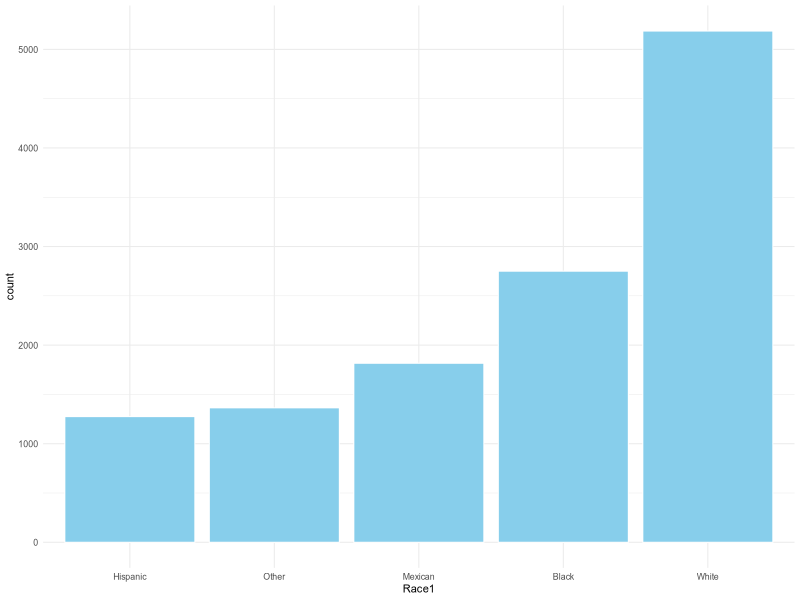

In [71]:
adults |> 
  mutate(Race1 =fct_infreq(Race1)) |> 
  mutate(Race1 = fct_rev(Race1)) |> 
  ggplot() + aes(Race1) + geom_bar(fill='skyblue', color='white') + theme_minimal()